Extracting kaggle and importing:

In [1]:
pip install kagglehub

In [2]:
import kagglehub
import pandas as pd
import os

# Downloaded the RT-IoT2022 dataset
path = kagglehub.dataset_download("supplejade/rt-iot2022real-time-internet-of-things")

# List files to find the CSV name
files = os.listdir(path)
print(f"Files in path: {files}")

# Loads the CSV
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print("Extraction Complete. Data Shape:", df.shape)
df.head()

c:\Users\Enzo\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files in path: ['RT_IOT2022.csv']
Extraction Complete. Data Shape: (123117, 85)


,no,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,...,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,...,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,...,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,...,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,...,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,...,0.0,2.981470e+07,2.981470e+07,2.981470e+07,2.981470e+07,0.0,64240,26847,502,MQTT_Publish


Transforming the data:

In [3]:
# 1. Remove rows with missing values
df.dropna(how='any',axis=0)

# 2. Removes duplicates
df.drop_duplicates()

# 3. Identify and removes constant columns
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=constant_cols)

# Displays it
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   no                        123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  str    
 4   service                   123117 non-null  str    
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio             123117 non-null  float64
 14 

Loading the data:

In [4]:
pip install seaborn 

Note: you may need to restart the kernel to use updated packages.


C:\Users\Enzo\AppData\Local\Temp\ipykernel_7060\1164223220.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Enzo\AppData\Local\Temp\ipykernel_7060\1164223220.py:11: UserWarning: 
The palette list has fewer values (7) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(


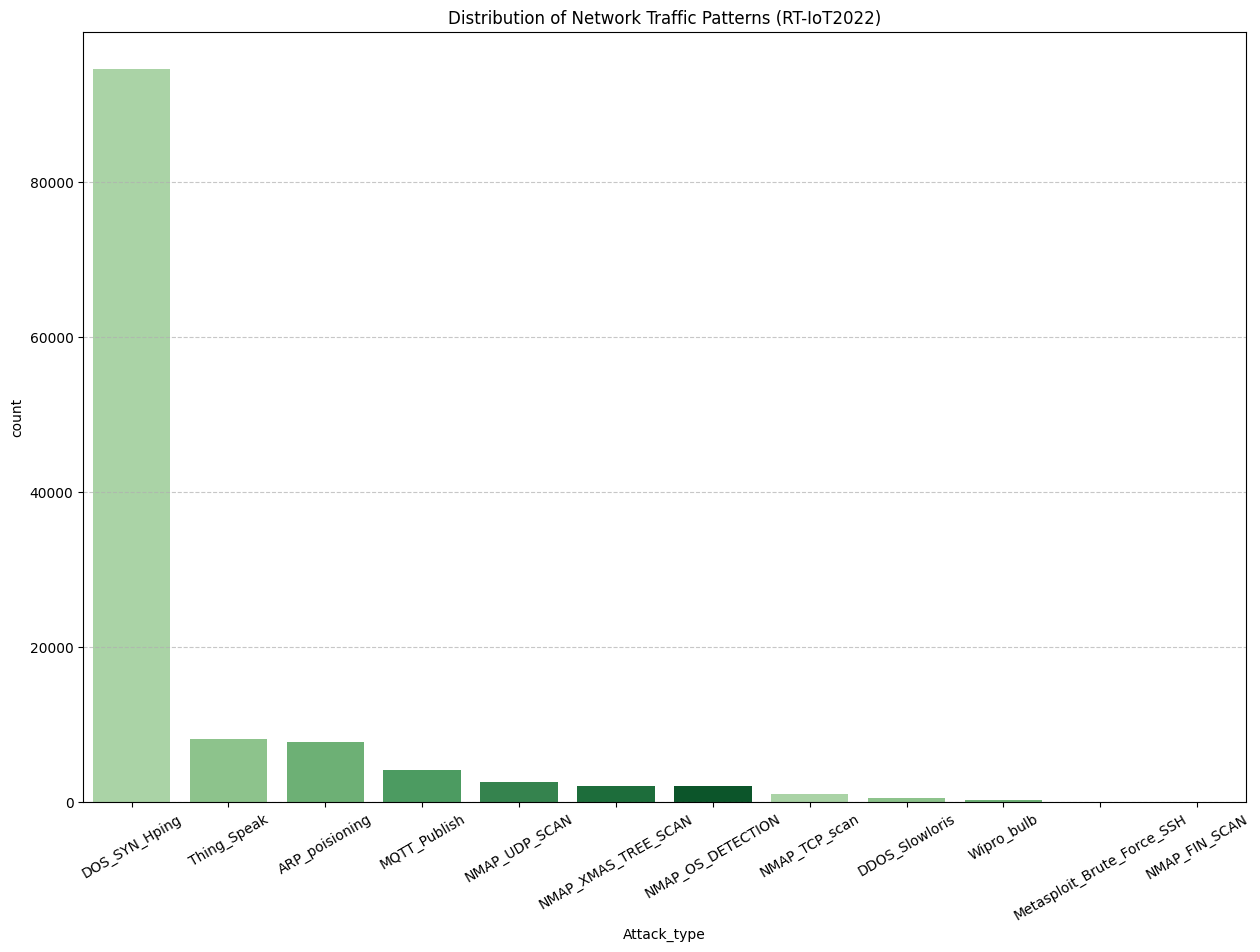

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical summary for numerical features
summary_stats = df.describe()

# Medium-dark green shades
green_palette = sns.color_palette("Greens", n_colors=10)[3:]

plt.figure(figsize=(15, 10))
sns.countplot(
    data=df,
    x='Attack_type',
    order=df['Attack_type'].value_counts().index,
    palette=green_palette
)

plt.title('Distribution of Network Traffic Patterns (RT-IoT2022)')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

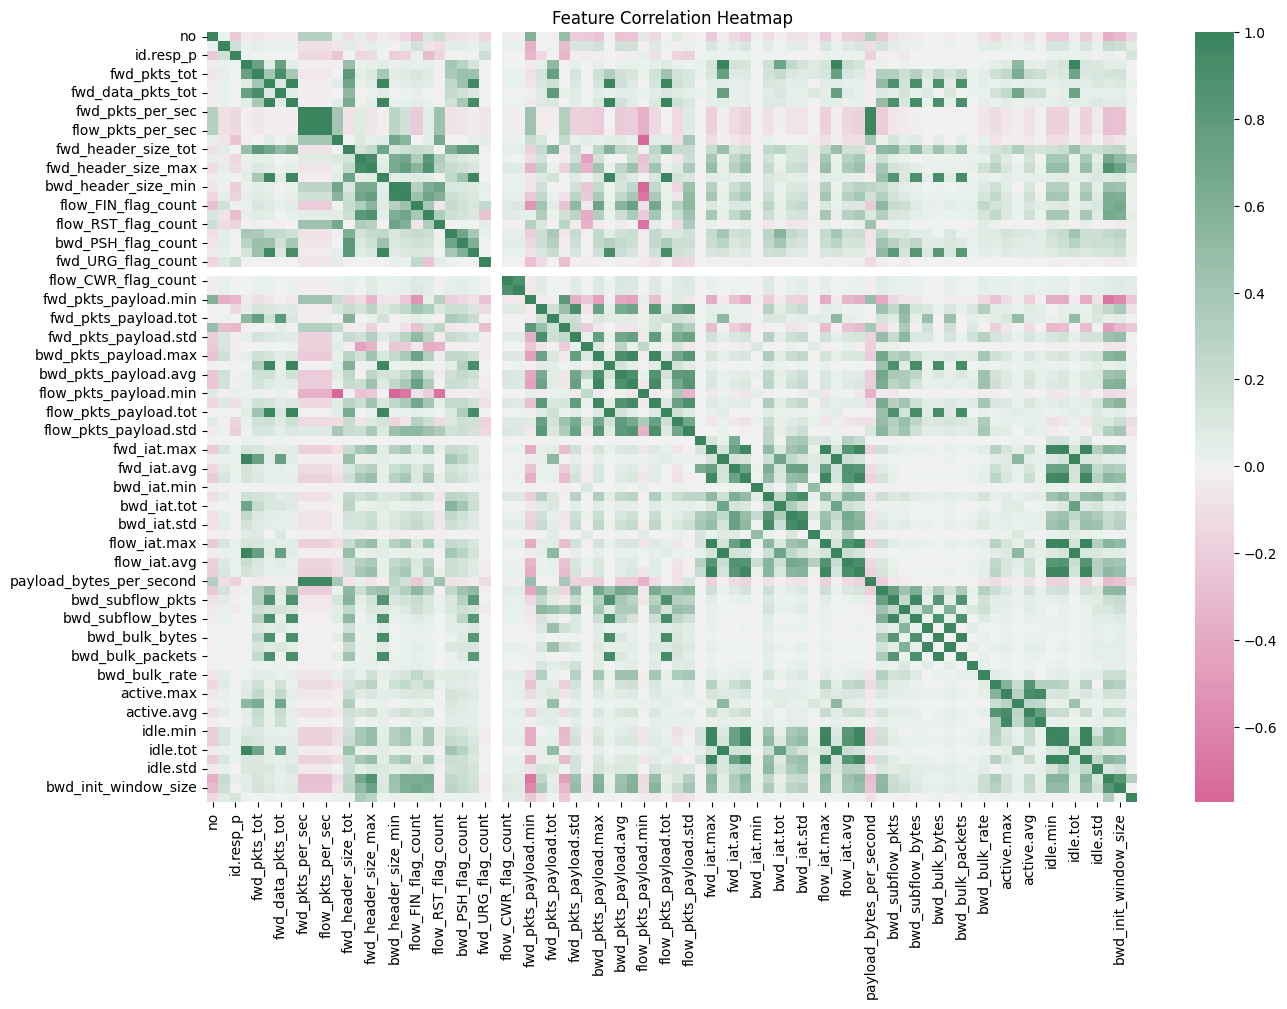

In [6]:
# Correlation Heatmap
corr = df.select_dtypes(include='number').corr()
top_corr_features = corr.index

plt.figure(figsize=(15,10))

# Green (for positive) and Pink (for negative)
custom_cmap = sns.diverging_palette(350, 145, as_cmap=True)

sns.heatmap(
    df[top_corr_features].corr(),
    annot=False,
    cmap=custom_cmap,
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()